In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
two_blobs = pd.read_csv('../notebooks/DATA/cluster_two_blobs.csv')

In [5]:
two_blobs_outlier = pd.read_csv('../notebooks/DATA/cluster_two_blobs_outliers.csv')

<Axes: xlabel='X1', ylabel='X2'>

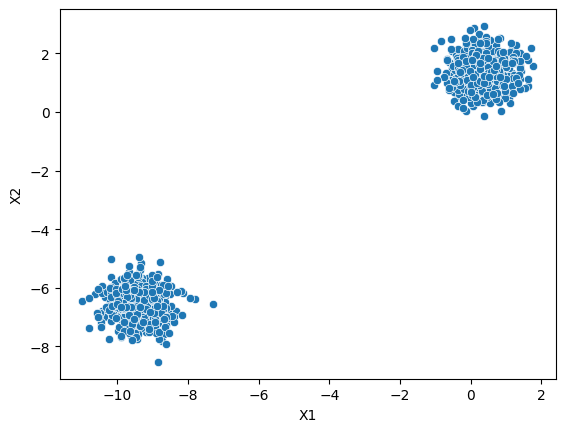

In [6]:
sns.scatterplot(data=two_blobs, x='X1', y='X2')

<Axes: xlabel='X1', ylabel='X2'>

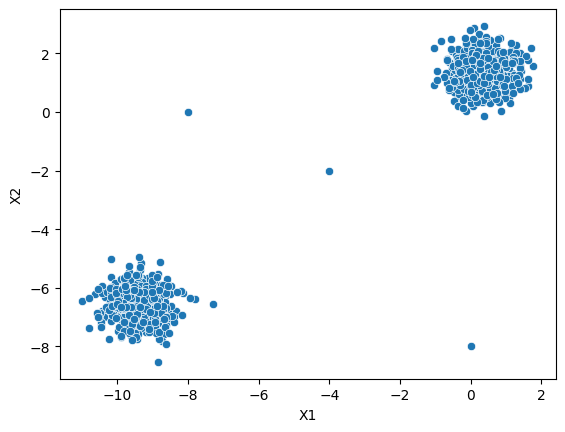

In [7]:
sns.scatterplot(data=two_blobs_outlier, x='X1', y='X2')

In [16]:
def display_categories(model, data):
    labels = model.fit_predict(data)
    sns.scatterplot(data=data, x='X1', y='X2', hue=labels, palette='Set1')

In [17]:
from sklearn.cluster import DBSCAN

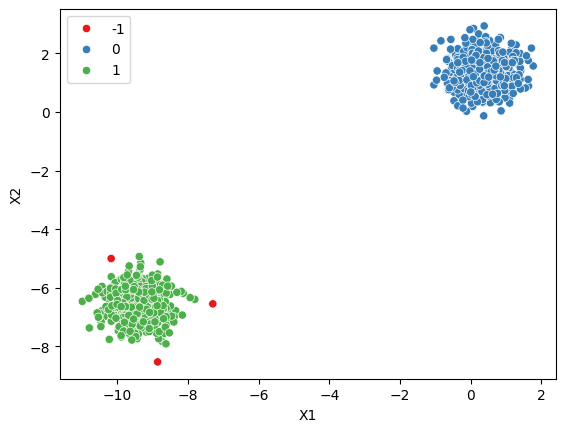

In [18]:
model = DBSCAN()

display_categories(model, two_blobs)

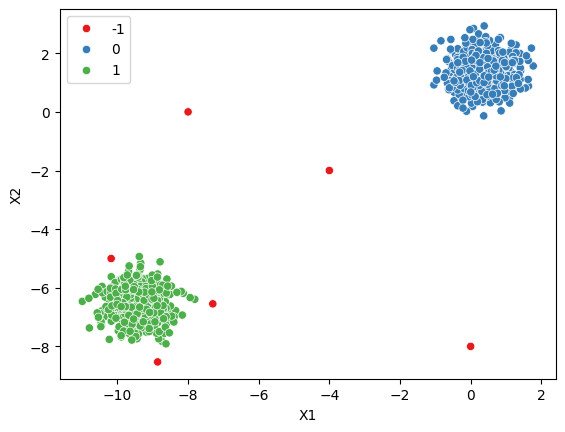

In [19]:
display_categories(model, two_blobs_outlier)

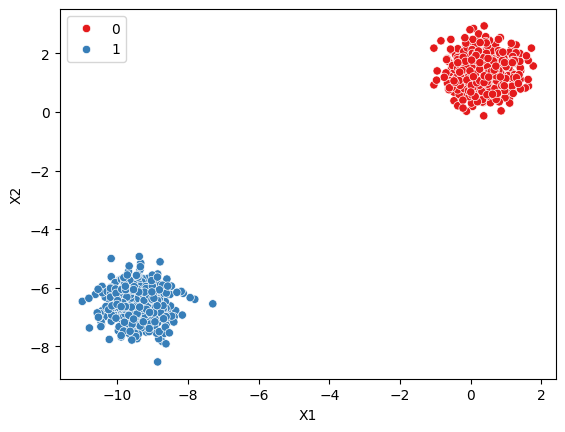

In [24]:
model = DBSCAN(eps=5)

display_categories(model, two_blobs)

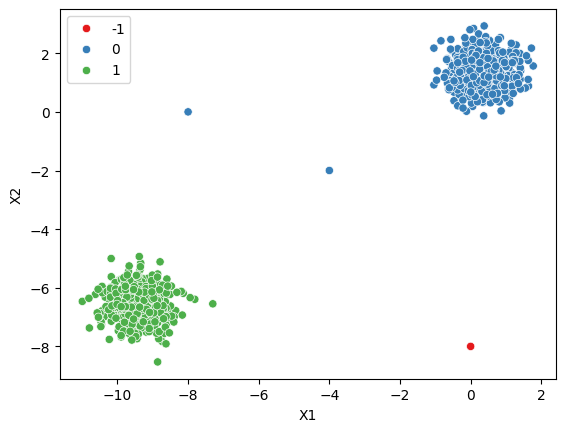

In [25]:
display_categories(model, two_blobs_outlier)

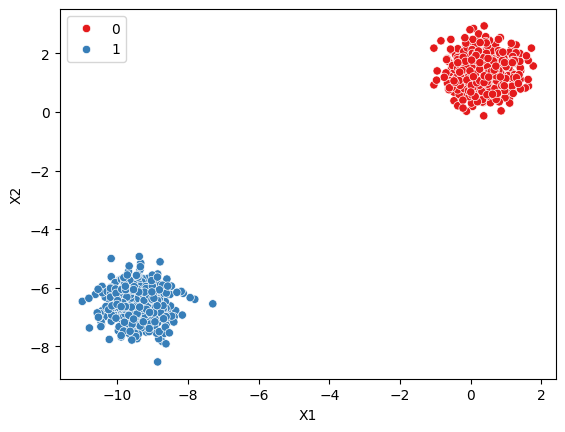

In [48]:
model = DBSCAN(eps=0.7)

display_categories(model, two_blobs)

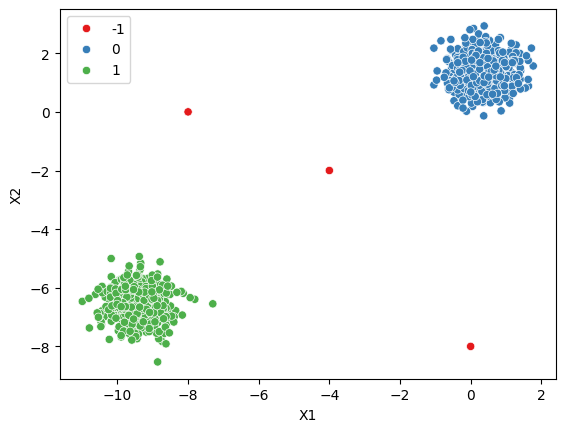

In [49]:
display_categories(model, two_blobs_outlier)

In [50]:
len(np.unique(model.labels_))

3

In [31]:
(np.sum(model.labels_ == -1) * 100) / len(model.labels_)

np.float64(0.29910269192422734)

In [32]:
len(model.labels_)

1003

In [54]:
outlier_percent = []
number_of_outlier = []

for eps in np.linspace(0.001, 7, 200):
    model = DBSCAN(eps=eps)
    model.fit(two_blobs_outlier)
    
    
    number_of_outlier.append(np.sum(model.labels_ == -1))
    outlier_percent.append((np.sum(model.labels_ == -1) * 100) / len(model.labels_))
    

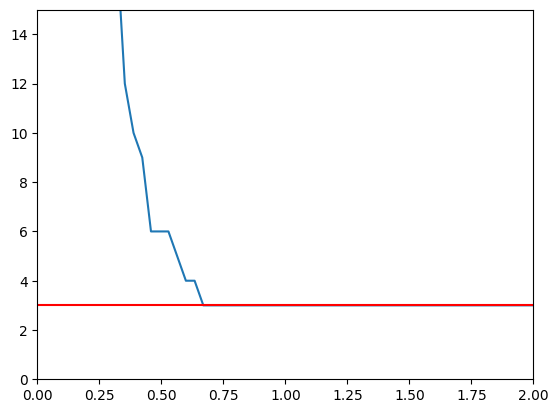

In [57]:
sns.lineplot(x=np.linspace(0.001, 7, 200), y=number_of_outlier)
plt.xlim(0,2)
plt.ylim(0, 15)
plt.hlines(y=3, xmin=0, xmax=2, colors='red')

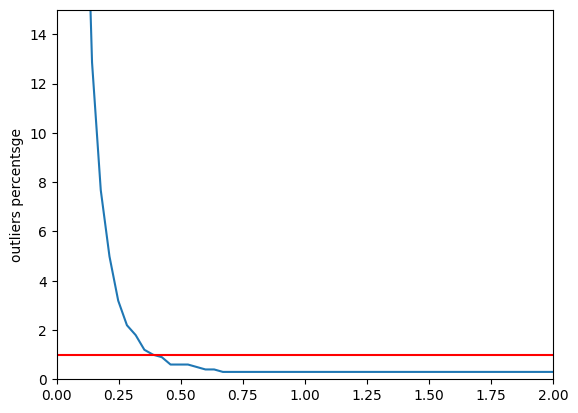

In [58]:
sns.lineplot(x=np.linspace(0.001, 7, 200), y=outlier_percent)
plt.xlim(0,2)
plt.ylim(0, 15)
plt.hlines(y=1, xmin=0, xmax=2, colors='red')
plt.ylabel('outliers percentsge');

In [59]:
outlier_percent = []
number_of_outliers = []

for n in np.arange(1,100):
    model = DBSCAN(min_samples=n)
    model.fit(two_blobs_outlier)
    
    
    number_of_outlier.append(np.sum(model.labels_ == -1))
    outlier_percent.append((np.sum(model.labels_ == -1) * 100) / len(model.labels_))
    

<Axes: >

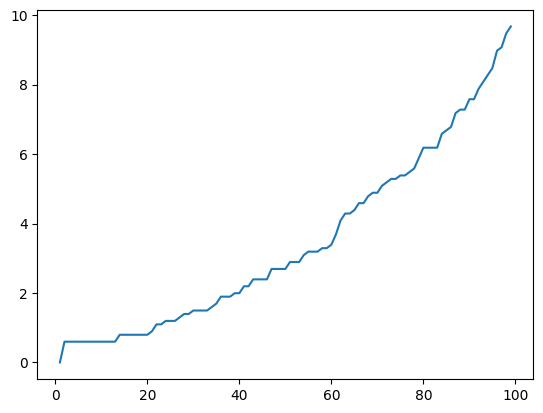

In [63]:
sns.lineplot(x=np.arange(1,100), y=outlier_percent)
#plt.xlim(0,2)
#plt.ylim(0, 15)
#plt.hlines(y=3, xmin=0, xmax=2, colors='red')